### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

import pybinding as pb
from pybinding.repository import graphene
from scipy.integrate import trapezoid

from tqdm import tqdm

import psutil
import os

Create folder to save plots

In [2]:
!mkdir output

mkdir: cannot create directory ‘output’: File exists


### Create the material and any defects

In [3]:
# Basis Vectors
a1 = graphene.a * np.array([1, np.sqrt(3)])/2
a2 = graphene.a * np.array([-1, np.sqrt(3)])/2
a3 = graphene.a * np.array([1, 0])

at = graphene.a/np.sqrt(3) # Distance between A and B sublattices

# Creating vacancy
def vacancy(position, radius):
    @pb.site_state_modifier
    def modifier(state, x, y):
        x0, y0 = position
        state[(x-x0)**2 + (y-y0)**2 < radius**2] = False
        return state
    return modifier

#width of hexagon
h = at/2 * 3/np.sqrt(3)
n = 17

# Create tightbinding model
### Vertical Configuration
##model = pb.Model(graphene.monolayer(), 
##                 pb.rectangle(50, 50), 
##                 vacancy(position=[0, (2 * n) * at/2], radius=0.1),
##                 vacancy(position=[0, (2 * n) * -at/2], radius=0.1))

## For two defects horizontal
##model = pb.Model(graphene.monolayer(), 
##                 pb.rectangle(50, 50), 
##                 vacancy(position=[(2 * n) * at/2, at/2], radius=0.09),
##                 vacancy(position=[(2 * n) * -at/2, at/2], radius=0.09))

## One defect center sublattice A (blue)
model = pb.Model(graphene.monolayer(), 
                 pb.rectangle(50, 50), 
                 vacancy(position=[0, -at/2], radius=0.09))

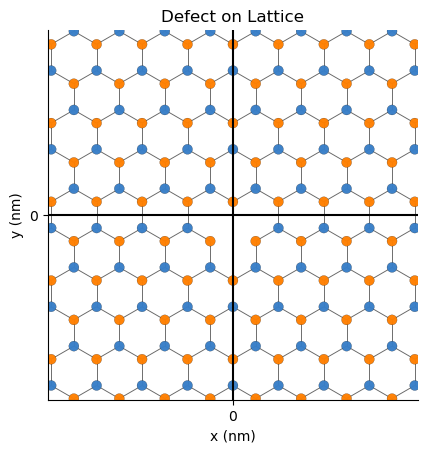

In [4]:
# Plotting energy ontop of lattice
#model.onsite_map.plot_contourf()
#pb.pltutils.colorbar(label="U (eV)")
model.plot()
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='black')
plt.axvline(0, color='black')
#plt.plot(2 * h, at/2, marker='x', color='red')
plt.title("Defect on Lattice")

plt.savefig("output/defect_on_lattice.png")

### LDOS with KPM

[0. 0.]
[-1.22975     2.12998948]


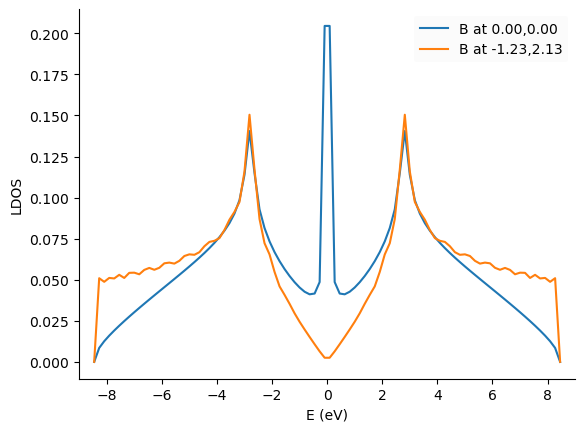

In [5]:
kpm = pb.kpm(model) # Kernal polynomial method. Instead of diagonalizing, explands everything in terms of Chebyshev polynomials

# Calculate LDOS close and far away
positions = [a1 * 0, a2 * 10]
sublattices = ['B', 'B'] # Which sub lattice we want to calculate for

for p, s in zip(positions, sublattices):
  print(p)
  ldos = kpm.calc_ldos(energy=np.linspace(-9, 9, 100), broadening=0.1, position=p, sublattice=s)
  ldos.plot(label=s + " at {pa:.2f},{pb:.2f}".format(pa=p[0], pb=p[1]))

pb.pltutils.legend()

plt.savefig("output/energy_ldos.png")

In [9]:
testarr = np.array([float("0.4")])

### Discrete Spatial LDOS at fixed energy

In [10]:
testarr[0]

np.float64(0.4)

In [11]:
size = 20 # half of lateral size
#energies = np.linspace(0, 1, 100) # eV
energies = np.array([0.4])

spatial_ldos = kpm.calc_spatial_ldos(energies,
                                     broadening=0.1, #eV
                                     shape=pb.rectangle(size*2))

Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:04:38 / ETA: 0:00:00


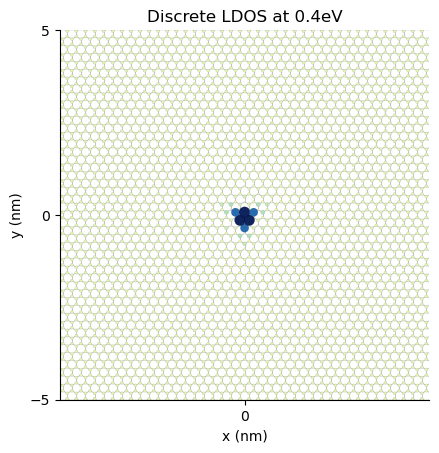

In [12]:
# Plotting
fig2, ax2 = plt.subplots()

smap = spatial_ldos.structure_map(energies[0])
smap.plot(site_radius=(0.02, 0.15))
ax2.set_xlim(-5, 5)
ax2.set_ylim(-5, 5)
ax2.set_xlabel("x (nm)")
ax2.set_ylabel("y (nm)")
ax2.set_title("Discrete LDOS at " + str(energies[0]) + "eV")

fig2.savefig("output/discrete_ldos.png")

### Integrating LDOS along energy

In [35]:
# Create 2D Arr so we can use scipy integration
ldos_arr = []
for en in energies:
    ldos_arr.append(spatial_ldos.structure_map(en).data)


ldos_arr = np.array(ldos_arr) # now rows are energy and cols are LDOS values

# Integrate
sum_ldos = trapezoid(ldos_arr, x=energies, axis=0)

print(sum_ldos.shape)

(61099,)


(-3.0, 3.0)

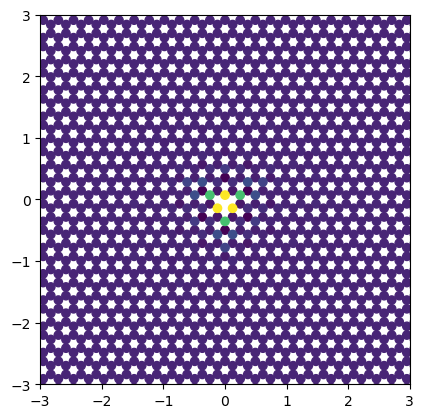

In [47]:
figA, axA = plt.subplots()

(X, Y, Z) = smap.spatial_map.positions

axA.scatter(X, Y, c=sum_ldos)
axA.set_aspect('equal')
axA.set_xlim(-3, 3)
axA.set_ylim(-3, 3)

### Continuous Spatial LDOS

In [48]:
(X, Y, Z) = smap.spatial_map.positions

# not integrated version
#psi2 = smap.data

# integrated version
psi2 = sum_ldos

mesh_size = 1000
x, y = np.meshgrid(np.linspace(-10, 10, mesh_size),
                   np.linspace(-10, 10, mesh_size))
z = x*0

# Interpolate by gaussian
# Every site impacts the points like a gaussian
# See Slater-Koster tightbinding for graphene band structure
for (X, Y, psi2) in tqdm(zip(X, Y, psi2)):
  z += psi2*np.exp(-((x-X)**2+(y-Y)**2)/(at)**2)

z_min, z_max = 0, np.abs(z).max()

61099it [23:01, 44.21it/s]


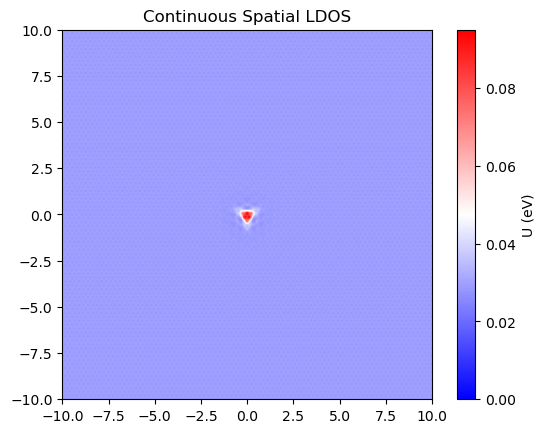

In [49]:
fig3, ax3 = plt.subplots()

c = ax3.pcolormesh(x, y, np.abs(z), cmap='bwr', vmin=z_min, vmax=z_max)
ax3.axis([x.min(), x.max(), y.min(), y.max()])
fig3.colorbar(c, ax=ax3, label="U (eV)")
ax3.set_aspect("equal")
#ax3.set_xlim(-5, 5)
#ax3.set_ylim(-5, 5)

ax3.set_title("Continuous Spatial LDOS")
fig3.savefig("output/continuous_ldos.png")

In [50]:
df = pd.DataFrame()

df['x'] = x.flatten()
df['y'] = y.flatten()
df['Re(z)'] = np.real(z).flatten()
#df['Im(z)'] = np.imag(z).flatten()
#df['MeshSize'] = mesh_size
#df['DiscreteSize'] = size
#df['LDOS Energy'] = energies[0]

df.to_csv("output/continous_ldos.csv", index=False)